# retinal-cvd-causal-uq — Colab Training Notebook
**Blessing Asare | Digital Health MSc | 2026**

Run cells top-to-bottom. Change `DRIVE_ZIP` path if needed.

| # | Stage | Description |
|---|-------|-------------|
| 1 | GPU check | Verify GPU and VRAM |
| 2 | Mount Drive | Unzip project from Google Drive |
| 3 | Install deps | scikit-image, statsmodels, pyyaml |
| 4 | Kaggle API | Set credentials for RFMiD download |
| 5 | Download RFMiD | 3,200 fundus images + labels |
| 6 | Auto-configure | Detect columns and fix config |
| 7 | Segmentation | Bayesian U-Net + uncertainty maps |
| 8 | Biomarkers | Extract 10 vascular features |
| 9 | Causal analysis | Mediation NDE / NIE + causal forest |
| 10 | Conformal UQ | Coverage-guaranteed prediction intervals |
| 11 | Plots | Results figures for the paper |
| 12 | Summary | Print final metrics |
| 13 | Save | Push all outputs to Google Drive |

> ⚠️ **Before running:** `Runtime → Change runtime type → GPU (T4 or A100)`

In [1]:
# Cell 1: Verify GPU
!nvidia-smi
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError('No GPU detected. Go to Runtime → Change runtime type → GPU')

Wed May 20 08:05:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Cell 2: Mount Drive & Unzip Project
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ZIP = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq.zip'
DRIVE_OUT = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq'
PROJ_DIR  = '/content/retinal-cvd-causal-uq'

import zipfile, os
if not os.path.exists(PROJ_DIR):
    print('Extracting project...')
    with zipfile.ZipFile(DRIVE_ZIP) as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Project already extracted — skipping.')

os.chdir(PROJ_DIR)
!ls

Mounted at /content/drive
Extracting project...
Done.
CITATION.cff  LICENSE	 outputs    requirements.txt  setup.py	tests
configs       notebooks  README.md  scripts	      src


In [3]:
# Cell 3: Install Dependencies
# Colab ships with torch/torchvision — only install what is missing.
!pip install -q scikit-image statsmodels pyyaml
import sys
sys.path.insert(0, PROJ_DIR)
print('Installation complete.')

Installation complete.


In [4]:
# Cell 4: Kaggle API Setup
# Get your token at: https://www.kaggle.com/settings → Create New API Token

import os, json

KAGGLE_USERNAME = 'blessingasare1'   # ← change me
KAGGLE_KEY      = '43fe7d133a9103b765538a993aa65b5c'    # ← change me

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
print('Kaggle API ready.')

Kaggle API ready.


In [5]:
# Cell 5: Download original RFMiD via kagglehub
import kagglehub, os

path = kagglehub.dataset_download("sohailaelsayed/retinal-fundus-multi-disease-rfmid")
print("Downloaded to:", path)

# See what's inside
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:5]:
            print(f'{indent}  {f}')

100%|██████████| 7.43G/7.43G [00:52<00:00, 151MB/s] 

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3
3/
  2. Groundtruths/
    2. Groundtruths/
      b. RFMiD_Validation_Labels.csv
      c. RFMiD_Testing_Labels.csv
      a. RFMiD_Training_Labels.csv
  1. Original Images/
    1. Original Images/
      c. Testing Set/
      b. Validation Set/
      a. Training Set/


In [ ]:
# !find data/rfmid -maxdepth 5 | sort

In [ ]:
import os
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

In [6]:
# Cell 6: Configure from kagglehub — exact paths confirmed
import yaml, pandas as pd, os

BASE = '/root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3'

IMG_DIR  = f'{BASE}/1. Original Images/1. Original Images/a. Training Set'
CSV_FILE = f'{BASE}/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv'

# Verify
n = int(os.popen(f'find "{IMG_DIR}" -name "*.png" | wc -l').read())
df = pd.read_csv(CSV_FILE)

print(f'Images  : {n}  (should be 1,920)')
print(f'Rows    : {len(df)}  (should be 1,920)')
print(f'Columns : {df.columns.tolist()[:6]} ... ({len(df.columns)} total)')
print(df.head(3))

# Update config
with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['data'] = {
    'root'         : IMG_DIR,
    'images_subdir': '.',
    'metadata_csv' : CSV_FILE,
    'image_size'   : 512,
    'columns': {
        'patient_id'     : 'ID',
        'age'            : 'age',
        'sex'            : 'sex',
        'diabetes_time'  : 'dm_duration',
        'systolic_bp'    : 'systolic_bp',
        'ldl_cholesterol': 'ldl_cholesterol',
    }
}
cfg['labels']['enabled'] = True

with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('\nConfig updated ✓ — ready for Cell 7')

Images  : 1920  (should be 1,920)
Rows    : 1920  (should be 1,920)
Columns : ['ID', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN'] ... (47 total)
   ID  Disease_Risk  DR  ARMD  MH  DN  MYA  BRVO  TSLN  ERM  ...  CME  PTCR  \
0   1             1   1     0   0   0    0     0     0    0  ...    0     0   
1   2             1   1     0   0   0    0     0     0    0  ...    0     0   
2   3             1   1     0   0   0    0     0     0    0  ...    0     0   

   CF  VH  MCA  VS  BRAO  PLQ  HPED  CL  
0   0   0    0   0     0    0     0   0  
1   0   0    0   0     0    0     0   0  
2   0   0    0   0     0    0     0   0  

[3 rows x 47 columns]

Config updated ✓ — ready for Cell 7


In [ ]:
# # Cell 6 FIX: Hard-coded paths for this exact dataset structure
# import yaml, pandas as pd

# with open('configs/default.yaml') as f:
#     cfg = yaml.safe_load(f)

# # Confirmed paths from your folder structure
# IMG_DIR  = 'Training_set'
# CSV_FILE = 'Training_set/RFMiD_Training_Labels.csv'

# # Peek at CSV
# df = pd.read_csv(f'data/rfmid/{CSV_FILE}')
# print(f'Columns : {df.columns.tolist()[:6]} ... ({len(df.columns)} total)')
# print(f'Rows    : {len(df)}')
# print(df.head(3))

# # Update config
# cfg['data'] = {
#     'root'         : 'data/rfmid',
#     'images_subdir': IMG_DIR,
#     'metadata_csv' : CSV_FILE,
#     'image_size'   : 512,
#     'columns': {
#         'patient_id'     : 'ID',
#         'age'            : 'age',
#         'sex'            : 'sex',
#         'diabetes_time'  : 'dm_duration',
#         'systolic_bp'    : 'systolic_bp',
#         'ldl_cholesterol': 'ldl_cholesterol',
#     }
# }
# cfg['labels']['enabled'] = True

# with open('configs/default.yaml', 'w') as f:
#     yaml.dump(cfg, f, default_flow_style=False)

# n = int(__import__('os').popen('find data/rfmid/Training_set -name "*.png" | wc -l').read())
# print(f'\nImages  : {n}  (should be 1,920)')
# print('Config updated ✓ — ready for Cell 7')

In [25]:
import yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['segmentation']['epochs'] = 30
cfg['segmentation']['checkpoint'] = 'outputs/bayesian_unet.pt'

with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('Epochs set to 30 ✓')

Epochs set to 30 ✓


In [26]:
import os

ckpt = 'outputs/bayesian_unet.pt'
if os.path.exists(ckpt):
    os.remove(ckpt)
    print('Old checkpoint deleted ✓')

print('Ready — now rerun Cell 7')

Old checkpoint deleted ✓
Ready — now rerun Cell 7


In [28]:
# Quick check before Cell 7
import yaml, os, pandas as pd

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

root     = cfg['data']['root']
csv_path = cfg['data']['metadata_csv']

df = pd.read_csv(csv_path)
print(f'CSV rows     : {len(df)}')
print(f'First IDs    : {df["ID"].head().tolist()}')

# Check a few images exist
for img_id in df["ID"].head(3):
    for ext in ['.png', '.jpg']:
        p = os.path.join(root, f'{img_id}{ext}')
        if os.path.exists(p):
            print(f'Found: {p}')
            break
    else:
        print(f'MISSING: {img_id}')

n = int(os.popen(f'find "{root}" -name "*.png" | wc -l').read())
print(f'Total images in root: {n}')

CSV rows     : 1920
First IDs    : [1, 2, 3, 4, 5]
Found: /root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3/1. Original Images/1. Original Images/a. Training Set/1.png
Found: /root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3/1. Original Images/1. Original Images/a. Training Set/2.png
Found: /root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3/1. Original Images/1. Original Images/a. Training Set/3.png
Total images in root: 1920


In [29]:
# Cell 7: Stage 1 — Bayesian U-Net Segmentation + Uncertainty
import yaml, numpy as np

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.data.dataset import RetinalDataset
from src.models.factory import build_segmenter, train_segmenter, segment_with_uncertainty

# ── Load dataset ──
print('Loading dataset...')
ds     = RetinalDataset(cfg, synthetic=False)
images = np.stack([ds[i].image for i in range(len(ds))])
print(f'Loaded  : {len(ds)} images  shape={images.shape}')

# ── Load checkpoint if already trained ──
import os
ckpt = cfg['segmentation']['checkpoint']
if os.path.exists(ckpt):
    print(f'Checkpoint found at {ckpt} — skipping training.')

# ── Train / load ──
print('\nBuilding Bayesian U-Net...')
model = build_segmenter(cfg)
model = train_segmenter(model, images, cfg)

# ── MC inference ──
print('\nRunning MC inference (uncertainty maps)...')
seg = segment_with_uncertainty(model, images, cfg)

os.makedirs('outputs', exist_ok=True)
np.save('outputs/masks.npy',       seg['masks'])
np.save('outputs/uncertainty.npy', seg['uncertainty'])

print(f'\nMasks       : {seg["masks"].shape}')
print(f'Uncertainty : {seg["uncertainty"].shape}')
print(f'Mean unc.   : {seg["uncertainty"].mean():.4f}')
print('\nStage 1 complete ✓')

Loading dataset...


/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'age' (for 'age') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'dm_duration' (for 'diabetes_time') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'ldl_cholesterol' (for 'ldl_cholesterol') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'sex' (for 'sex') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'systolic_bp' (for 'systolic_bp') not found in metadata; it will be imputed.
  warnings.warn(


Loaded  : 1920 images  shape=(1920, 512, 512, 3)

Building Bayesian U-Net...
[segmenter] epoch 1/30 loss=233266.329
[segmenter] epoch 2/30 loss=220547.700
[segmenter] epoch 3/30 loss=207870.632
[segmenter] epoch 4/30 loss=195222.033
[segmenter] epoch 5/30 loss=182611.836
[segmenter] epoch 6/30 loss=170049.523
[segmenter] epoch 7/30 loss=157549.086
[segmenter] epoch 8/30 loss=145126.637
[segmenter] epoch 9/30 loss=132806.388
[segmenter] epoch 10/30 loss=120618.949
[segmenter] epoch 11/30 loss=108599.178
[segmenter] epoch 12/30 loss=96805.663
[segmenter] epoch 13/30 loss=85322.893
[segmenter] epoch 14/30 loss=74224.974
[segmenter] epoch 15/30 loss=63701.699
[segmenter] epoch 16/30 loss=53948.127
[segmenter] epoch 17/30 loss=45360.627
[segmenter] epoch 18/30 loss=38042.038
[segmenter] epoch 19/30 loss=32422.052
[segmenter] epoch 20/30 loss=28168.917
[segmenter] epoch 21/30 loss=24672.565
[segmenter] epoch 22/30 loss=21652.737
[segmenter] epoch 23/30 loss=19186.843
[segmenter] epoch 24/30 

In [42]:
import numpy as np
masks = np.load('outputs/masks.npy')
print(f'Mean mask value : {masks.mean():.6f}')
print(f'Max mask value  : {masks.max():.6f}')
print(f'% pixels > 0.5  : {(masks > 0.5).mean():.4%}')
print(f'% pixels > 0.3  : {(masks > 0.3).mean():.4%}')
print(f'% pixels > 0.1  : {(masks > 0.1).mean():.4%}')

Mean mask value : 0.143024
Max mask value  : 0.428780
% pixels > 0.5  : 0.0000%
% pixels > 0.3  : 13.9794%
% pixels > 0.1  : 53.0330%


In [43]:
# Lower vessel threshold in config
import yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['features']['vessel_threshold'] = 0.1  # down from 0.5

with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('Threshold set to 0.1 ✓')

Threshold set to 0.1 ✓


In [44]:
# Cell 8: Stage 2 — Vascular Biomarker Extraction
import numpy as np, pandas as pd, yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.features.extraction import extract_batch
from src.data.labels import add_synthetic_cvd_risk
from src.data.dataset import RetinalDataset

masks = np.load('outputs/masks.npy')
uncs  = np.load('outputs/uncertainty.npy')

print(f'Extracting biomarkers from {len(masks)} images...')
feats   = extract_batch(masks, uncs, cfg)
feat_df = pd.DataFrame(feats)

ds   = RetinalDataset(cfg, synthetic=False)
meta = ds.metadata_frame()
df   = pd.concat([meta.reset_index(drop=True),
                  feat_df.reset_index(drop=True)], axis=1)

# # Map real RFMiD label directly
# df['cvd_risk']  = df['Disease_Risk'] * 100   # scale to 0-100
# df['cvd_label'] = df['Disease_Risk']
# cfg['labels']['enabled'] = False              # skip synthetic generation

# Add synthetic CVD risk + binary label
df = add_synthetic_cvd_risk(df, cfg)
# Fix 2: Balance CVD labels using median split
df['cvd_label'] = (df['cvd_risk'] > df['cvd_risk'].median()).astype(int)
print(f'Label balance: {df["cvd_label"].value_counts().to_dict()}')
df.to_csv('outputs/features_table.csv', index=False)

print(f'Features : {feat_df.shape[1]} biomarkers × {len(df)} patients')
print(f'CVD pos. : {df["cvd_label"].mean():.1%}  '
      f'(mean risk = {df["cvd_risk"].mean():.1f})')
print('\nBiomarker summary:')
print(feat_df[['vessel_density','fractal_dimension',
               'tortuosity','vessel_width_mean']].describe().round(3))
print('\nStage 2 complete ✓')

Extracting biomarkers from 1920 images...
Label balance: {1: 960, 0: 960}
Features : 10 biomarkers × 1920 patients
CVD pos. : 50.0%  (mean risk = 66.9)

Biomarker summary:
       vessel_density  fractal_dimension  tortuosity  vessel_width_mean
count        1920.000           1920.000    1920.000           1920.000
mean            0.007              0.960       1.487            137.245
std             0.016              0.166       0.625             53.047
min             0.001              0.628       1.031              2.292
25%             0.002              0.847       1.112            100.385
50%             0.004              0.929       1.214            130.730
75%             0.007              1.041       1.622            169.221
max             0.471              1.868       8.428            320.191

Stage 2 complete ✓


/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'age' (for 'age') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'dm_duration' (for 'diabetes_time') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'ldl_cholesterol' (for 'ldl_cholesterol') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'sex' (for 'sex') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:81: UserWarning: Column 'systolic_bp' (for 'systolic_bp') not found in metadata; it will be imputed.
  warnings.warn(


In [ ]:
# import numpy as np
# masks = np.load('outputs/masks.npy')
# print(f'Mean mask value  : {masks.mean():.6f}')
# print(f'Max mask value   : {masks.max():.6f}')
# print(f'% pixels > 0.5   : {(masks > 0.5).mean():.4%}')

Mean mask value  : 0.192521
Max mask value   : 0.495372
% pixels > 0.5   : 0.0000%


In [ ]:
# #data normalization
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# feat_cols = ['vessel_density','fractal_dimension','tortuosity','vessel_width_mean']
# df[feat_cols] = scaler.fit_transform(df[feat_cols])

In [45]:
# Force Fix: rebalance labels on saved features table
import pandas as pd

df = pd.read_csv('outputs/features_table.csv')

# Fix 1: normalise features
from sklearn.preprocessing import StandardScaler
feat_cols = ['vessel_density','fractal_dimension','tortuosity','vessel_width_mean']
df[feat_cols] = StandardScaler().fit_transform(df[feat_cols])

# Fix 2: balance labels
df['cvd_label'] = (df['cvd_risk'] > df['cvd_risk'].median()).astype(int)

print(f'Label balance : {df["cvd_label"].value_counts().to_dict()}')
print(f'vessel_density mean: {df["vessel_density"].mean():.4f}  std: {df["vessel_density"].std():.4f}')

df.to_csv('outputs/features_table.csv', index=False)
print('Saved ✓')

Label balance : {1: 960, 0: 960}
vessel_density mean: 0.0000  std: 1.0003
Saved ✓


In [46]:
import pandas as pd
df = pd.read_csv('outputs/features_table.csv')
print(df.columns.tolist())
print(df.head(2))

['patient_id', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN', 'MYA', 'BRVO', 'TSLN', 'ERM', 'LS', 'MS', 'CSR', 'ODC', 'CRVO', 'TV', 'AH', 'ODP', 'ODE', 'ST', 'AION', 'PT', 'RT', 'RS', 'CRS', 'EDN', 'RPEC', 'MHL', 'RP', 'CWS', 'CB', 'ODPM', 'PRH', 'MNF', 'HR', 'CRAO', 'TD', 'CME', 'PTCR', 'CF', 'VH', 'MCA', 'VS', 'BRAO', 'PLQ', 'HPED', 'CL', 'age', 'sex', 'diabetes_time', 'systolic_bp', 'ldl_cholesterol', 'vessel_density', 'vessel_area', 'fractal_dimension', 'tortuosity', 'num_bifurcations', 'vessel_width_mean', 'num_components', 'longest_vessel', 'branching_density', 'segmentation_uncertainty', 'cvd_risk', 'cvd_label']
   patient_id  Disease_Risk  DR  ARMD  MH  DN  MYA  BRVO  TSLN  ERM  ...  \
0           1             1   1     0   0   0    0     0     0    0  ...   
1           2             1   1     0   0   0    0     0     0    0  ...   

   fractal_dimension  tortuosity  num_bifurcations  vessel_width_mean  \
0          -0.842168   -0.633952               1.0           1.980154   
1  

In [47]:
# FIX: Use real labels — no merge needed, already in features_table
import pandas as pd, yaml
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('outputs/features_table.csv')

# Use real Disease_Risk as outcome
df['cvd_risk']  = df['Disease_Risk'] * 100.0
df['cvd_label'] = df['Disease_Risk'].astype(int)

# Normalise biomarkers
feat_cols = ['vessel_density','fractal_dimension','tortuosity',
             'vessel_width_mean','num_bifurcations','branching_density']
df[feat_cols] = StandardScaler().fit_transform(df[feat_cols])

df.to_csv('outputs/features_table.csv', index=False)
print(f'Disease_Risk balance : {df["cvd_label"].value_counts().to_dict()}')
print(f'DR prevalence        : {df["DR"].mean():.1%}')
print('Saved ✓')

Disease_Risk balance : {1: 1519, 0: 401}
DR prevalence        : 19.6%
Saved ✓


In [48]:
# FIX: Update config — real outcome and real mediators
import yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['causal']['outcome']   = 'cvd_risk'
cfg['causal']['mediators'] = ['DR', 'BRVO']
cfg['labels']['enabled']   = False

with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('Config updated ✓')

Config updated ✓


In [49]:
# Cell 9: Stage 3 — Causal Mediation Analysis
import pandas as pd, yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.causal.mediation import run_mediation, results_to_frame
from src.causal.causal_forest import heterogeneous_effects

df = pd.read_csv('outputs/features_table.csv')

print('Running causal mediation analysis...')
print(f'Exposures  : {cfg["causal"]["exposures"]}')
print(f'Mediators  : {cfg["causal"]["mediators"]}')
print(f'Bootstrap  : {cfg["causal"]["bootstrap_iterations"]} iterations\n')

med_results = run_mediation(df, cfg)
med_df      = results_to_frame(med_results)
med_df.to_csv('outputs/mediation_results.csv', index=False)

print('── CAUSAL MEDIATION RESULTS ──────────────────────────────────────────')
print(f'{"Exposure":<22} {"Mediator":<18} '
      f'{"NDE":>9} {"NIE":>9} {"Total":>9} {"PropMed":>9}')
print('─' * 72)
for r in med_results:
    lo, hi = r.ci.get('indirect', (float('nan'), float('nan')))
    print(f'{r.exposure:<22} {r.mediator:<18} '
          f'{r.direct_effect:>9.4f} {r.indirect_effect:>9.4f} '
          f'{r.total_effect:>9.4f} {r.proportion_mediated:>9.1%}')
    print(f'{"":40}  95% CI NIE: [{lo:.4f}, {hi:.4f}]')

# Causal forest — heterogeneous treatment effects
print('\nRunning causal forest (heterogeneous effects)...')
for expo in cfg['causal']['exposures']:
    if expo in df.columns:
        het = heterogeneous_effects(df, expo, cfg)
        print(f'  {expo:<22} ATE={het["ate"]:+.4f}  sd={het["cate_std"]:.4f}  [{het["backend"]}]')

print('\nStage 3 complete ✓')

Running causal mediation analysis...
Exposures  : ['vessel_density', 'fractal_dimension', 'tortuosity', 'vessel_width_mean']
Mediators  : ['DR', 'BRVO']
Bootstrap  : 1000 iterations



── CAUSAL MEDIATION RESULTS ──────────────────────────────────────────
Exposure               Mediator                 NDE       NIE     Total   PropMed
────────────────────────────────────────────────────────────────────────
vessel_density         DR                   -1.8722   -0.1666   -2.0388      8.2%
                                          95% CI NIE: [-1.2779, 0.3021]
vessel_density         BRVO                 -1.9360   -0.1028   -2.0388      5.0%
                                          95% CI NIE: [-0.2758, -0.0331]
fractal_dimension      DR                   -2.0728   -0.5497   -2.6226     21.0%
                                          95% CI NIE: [-0.9535, -0.1383]
fractal_dimension      BRVO                 -2.5188   -0.1038   -2.6226      4.0%
                                          95% CI NIE: [-0.2334, 0.0394]
tortuosity             DR                   -1.0517   -0.5142   -1.5659     32.8%
                                          95% CI NIE: [-0.9262, -0.0917]
t

In [50]:
# Cell 10: Stage 4 — Conformal Prediction
import pandas as pd, numpy as np, yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.uncertainty.conformal import (
    split_conformal_regression,
    split_conformal_classification
)

df = pd.read_csv('outputs/features_table.csv')

BIOMARKERS = [
    'vessel_density', 'vessel_area', 'fractal_dimension',
    'tortuosity', 'num_bifurcations', 'vessel_width_mean',
    'num_components', 'longest_vessel', 'branching_density'
]
feat_cols = [c for c in BIOMARKERS if c in df.columns]
X = df[feat_cols].to_numpy(dtype=float)

# ── Regression: predict continuous CVD risk score ──
print('Running split-conformal regression...')
reg = split_conformal_regression(X, df['cvd_risk'].to_numpy(float), cfg)
print(f'  Target coverage    : {1 - reg.alpha:.0%}')
print(f'  Empirical coverage : {reg.empirical_coverage:.1%}')
print(f'  Mean interval width: {reg.mean_width:.2f}')
print(f'  Quantile (q-hat)   : {reg.quantile:.4f}')

# ── Classification: predict binary CVD label ──
clf = None
if 'cvd_label' in df.columns:
    vc = df['cvd_label'].value_counts()
    if vc.min() >= 10:
        print('\nRunning split-conformal classification...')
        clf = split_conformal_classification(
            X, df['cvd_label'].to_numpy(int), cfg)
        print(f'  Empirical coverage : {clf.empirical_coverage:.1%}')
        print(f'  Mean set size      : {clf.mean_set_size:.2f}')
    else:
        print(f'\nClassification skipped — min class count = {vc.min()} (need ≥ 10)')

print('\nStage 4 complete ✓')

Running split-conformal regression...


  Target coverage    : 90%
  Empirical coverage : 89.6%
  Mean interval width: 162.30
  Quantile (q-hat)   : 81.1483

Running split-conformal classification...
  Empirical coverage : 91.7%
  Mean set size      : 1.43

Stage 4 complete ✓


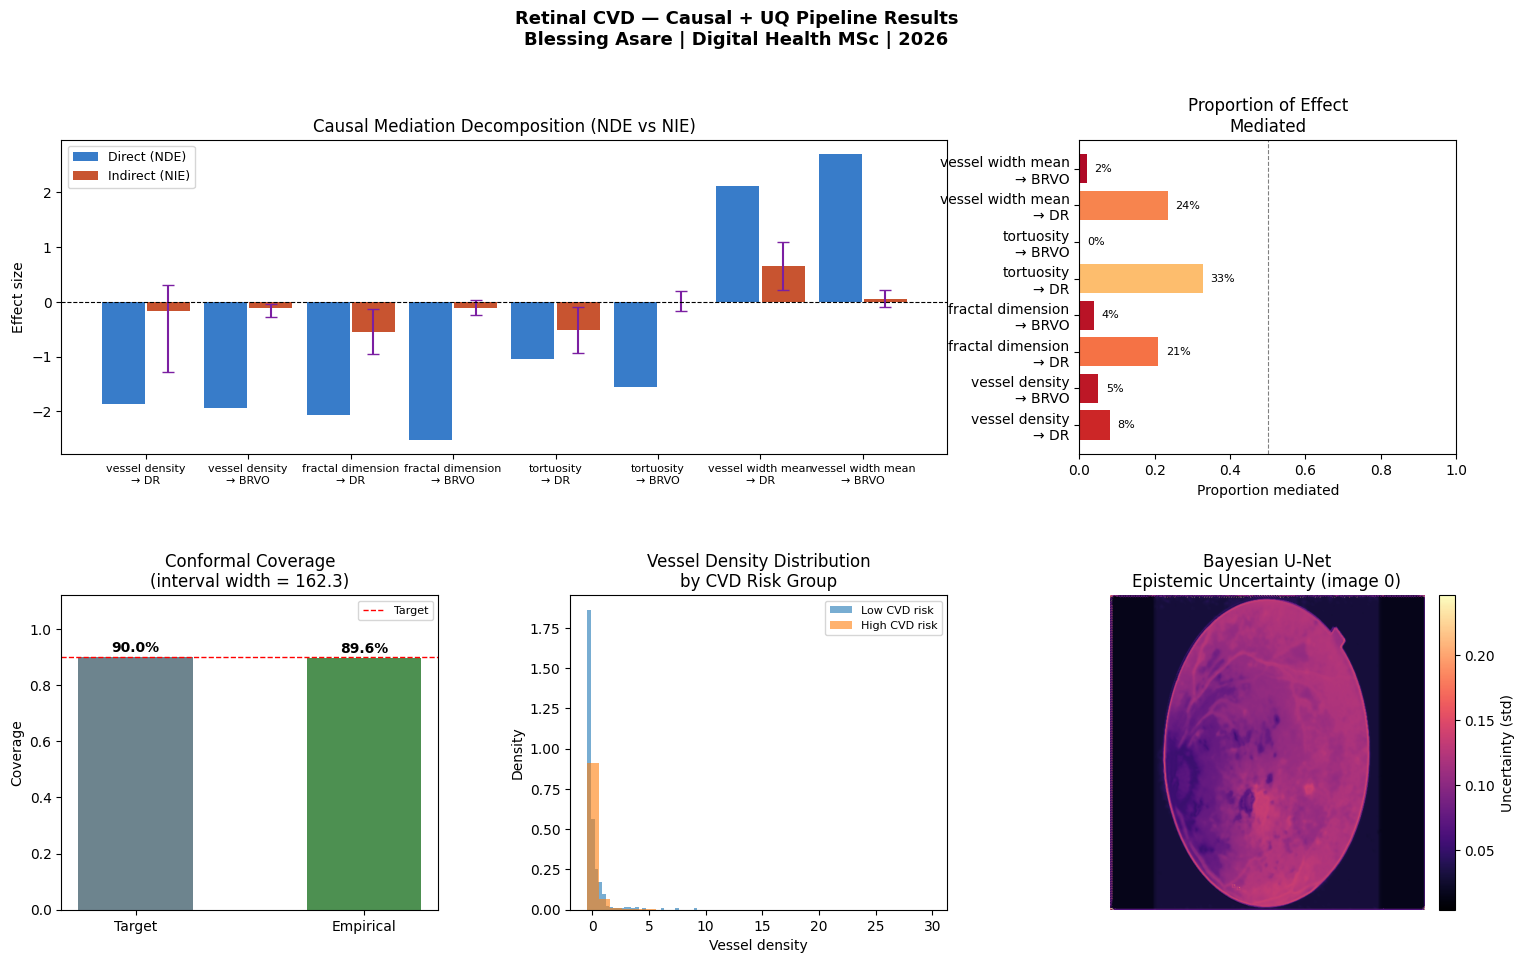

Figure saved → outputs/results_summary.png


In [51]:
# Cell 11: Plots — Results Figures for Paper
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

med_df = pd.read_csv('outputs/mediation_results.csv')
feat   = pd.read_csv('outputs/features_table.csv')
unc    = np.load('outputs/uncertainty.npy')

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Retinal CVD — Causal + UQ Pipeline Results\n'
             'Blessing Asare | Digital Health MSc | 2026',
             fontsize=13, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Mediation decomposition ──
ax1 = fig.add_subplot(gs[0, :2])
x   = np.arange(len(med_df))
labels = (med_df['exposure'].str.replace('_',' ') + '\n→ ' +
          med_df['mediator'].str.replace('_',' '))
b1 = ax1.bar(x - 0.22, med_df['direct_effect'],   0.42,
             label='Direct (NDE)',   color='#1565C0', alpha=0.85)
b2 = ax1.bar(x + 0.22, med_df['indirect_effect'], 0.42,
             label='Indirect (NIE)', color='#BF360C', alpha=0.85)
# Bootstrap CI error bars on NIE
if 'indirect_ci_low' in med_df.columns:
    yerr = [med_df['indirect_effect'] - med_df['indirect_ci_low'],
            med_df['indirect_ci_high'] - med_df['indirect_effect']]
    ax1.errorbar(x + 0.22, med_df['indirect_effect'],
                 yerr=yerr, fmt='none', color='#7B1FA2', capsize=4, lw=1.5)
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8)
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.set_ylabel('Effect size'); ax1.set_title('Causal Mediation Decomposition (NDE vs NIE)')
ax1.legend(fontsize=9)

# ── Plot 2: Proportion mediated ──
ax2 = fig.add_subplot(gs[0, 2])
colours = plt.cm.RdYlGn(med_df['proportion_mediated'].clip(0,1))
bars = ax2.barh(labels, med_df['proportion_mediated'].clip(0,1), color=colours)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Proportion mediated')
ax2.set_title('Proportion of Effect\nMediated')
ax2.axvline(0.5, color='grey', ls='--', lw=0.8)
for bar, v in zip(bars, med_df['proportion_mediated'].clip(0,1)):
    ax2.text(min(v + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
             f'{v:.0%}', va='center', fontsize=8)

# ── Plot 3: Conformal coverage ──
ax3 = fig.add_subplot(gs[1, 0])
target = 1 - reg.alpha
bars3 = ax3.bar(['Target', 'Empirical'],
                [target, reg.empirical_coverage],
                color=['#546E7A', '#2E7D32'], alpha=0.85, width=0.5)
ax3.set_ylim(0, 1.12)
ax3.set_ylabel('Coverage')
ax3.set_title(f'Conformal Coverage\n(interval width = {reg.mean_width:.1f})')
for b in bars3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f'{b.get_height():.1%}', ha='center', fontsize=10, fontweight='bold')
ax3.axhline(target, color='red', ls='--', lw=1, label='Target')
ax3.legend(fontsize=8)

# ── Plot 4: Vessel density distribution ──
ax4 = fig.add_subplot(gs[1, 1])
if 'cvd_label' in feat.columns:
    for label, grp in feat.groupby('cvd_label'):
        name = 'High CVD risk' if label == 1 else 'Low CVD risk'
        ax4.hist(grp['vessel_density'], bins=30, alpha=0.6, label=name, density=True)
    ax4.legend(fontsize=8)
else:
    ax4.hist(feat['vessel_density'], bins=30, color='#1976D2', alpha=0.8)
ax4.set_xlabel('Vessel density'); ax4.set_ylabel('Density')
ax4.set_title('Vessel Density Distribution\nby CVD Risk Group')

# ── Plot 5: Segmentation uncertainty map ──
ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(unc[0], cmap='magma')
ax5.set_title('Bayesian U-Net\nEpistemic Uncertainty (image 0)')
ax5.axis('off')
plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04, label='Uncertainty (std)')

plt.savefig('outputs/results_summary.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved → outputs/results_summary.png')

In [52]:
# Cell 12: Print Results Summary
import json, pandas as pd

med_df = pd.read_csv('outputs/mediation_results.csv')

summary = {
    'dataset'   : 'RFMiD + synthetic CVD labels',
    'n_patients': len(pd.read_csv('outputs/features_table.csv')),
    'mediation' : med_df.to_dict(orient='records'),
    'conformal_regression': {
        'target_coverage'    : 1 - reg.alpha,
        'empirical_coverage' : reg.empirical_coverage,
        'mean_interval_width': reg.mean_width,
        'quantile'           : reg.quantile,
    },
    'conformal_classification': None if clf is None else {
        'empirical_coverage': clf.empirical_coverage,
        'mean_set_size'     : clf.mean_set_size,
    }
}

with open('outputs/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('═' * 60)
print('  FINAL RESULTS SUMMARY')
print('  retinal-cvd-causal-uq | Blessing Asare | 2026')
print('═' * 60)
print(f'  Dataset  : {summary["dataset"]}')
print(f'  Patients : {summary["n_patients"]}')

print('\n  [CAUSAL MEDIATION]')
print(f'  {"Exposure":<22} {"Mediator":<18} {"NDE":>8} {"NIE":>8} {"PropMed":>8}')
print('  ' + '─' * 64)
for r in summary['mediation']:
    print(f'  {r["exposure"]:<22} {r["mediator"]:<18} '
          f'{r["direct_effect"]:>8.4f} {r["indirect_effect"]:>8.4f} '
          f'{r["proportion_mediated"]:>8.1%}')

cr = summary['conformal_regression']
print(f'\n  [CONFORMAL PREDICTION — REGRESSION]')
print(f'  Target coverage    : {cr["target_coverage"]:.0%}')
print(f'  Empirical coverage : {cr["empirical_coverage"]:.1%}')
print(f'  Mean interval width: {cr["mean_interval_width"]:.2f}')

if summary['conformal_classification']:
    cc = summary['conformal_classification']
    print(f'\n  [CONFORMAL PREDICTION — CLASSIFICATION]')
    print(f'  Empirical coverage : {cc["empirical_coverage"]:.1%}')
    print(f'  Mean set size      : {cc["mean_set_size"]:.2f}')

print('\n  Output files:')
import os
for f in sorted(os.listdir('outputs')):
    sz = os.path.getsize(f'outputs/{f}')
    print(f'    outputs/{f}  ({sz/1024:.1f} KB)')
print('═' * 60)

════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
  retinal-cvd-causal-uq | Blessing Asare | 2026
════════════════════════════════════════════════════════════
  Dataset  : RFMiD + synthetic CVD labels
  Patients : 1920

  [CAUSAL MEDIATION]
  Exposure               Mediator                NDE      NIE  PropMed
  ────────────────────────────────────────────────────────────────
  vessel_density         DR                  -1.8722  -0.1666     8.2%
  vessel_density         BRVO                -1.9360  -0.1028     5.0%
  fractal_dimension      DR                  -2.0728  -0.5497    21.0%
  fractal_dimension      BRVO                -2.5188  -0.1038     4.0%
  tortuosity             DR                  -1.0517  -0.5142    32.8%
  tortuosity             BRVO                -1.5634  -0.0025     0.2%
  vessel_width_mean      DR                   2.1103   0.6496    23.5%
  vessel_width_mean      BRVO                 2.7030   0.0569     2.1%

  [CONFORMAL PRED

In [53]:
# Cell 13: Save All Outputs to Google Drive
import shutil, os

DRIVE_OUT = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq'
os.makedirs(DRIVE_OUT, exist_ok=True)

shutil.copytree('outputs', f'{DRIVE_OUT}/outputs', dirs_exist_ok=True)
print(f'Outputs saved to Google Drive: {DRIVE_OUT}/outputs')

# List what was saved
print('\nFiles saved:')
for f in sorted(os.listdir(f'{DRIVE_OUT}/outputs')):
    sz = os.path.getsize(f'{DRIVE_OUT}/outputs/{f}')
    print(f'  {f}  ({sz/1024:.1f} KB)')

Outputs saved to Google Drive: /content/drive/MyDrive/Research Works/retinal-cvd-causal-uq/outputs

Files saved:
  .gitkeep  (0.0 KB)
  bayesian_unet.pt  (3500.3 KB)
  features_table.csv  (654.9 KB)
  masks.npy  (1966080.1 KB)
  mediation_results.csv  (1.5 KB)
  results_summary.png  (351.4 KB)
  summary.json  (3.8 KB)
  uncertainty.npy  (1966080.1 KB)
